# FraudShield — Model Training + MLflow
**Model:** LightGBM (binary classification, PR-AUC optimised)  
**Target:** PR-AUC > 0.50 on time-based test set (strict temporal split — no leakage)  
**MLflow:** Tracks every run — params, metrics, plots, model artifact, registry

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import lightgbm as lgb
import mlflow

from src.training.train import train
from src.training.evaluate import (
    compute_metrics, find_best_threshold,
    plot_pr_curve, plot_confusion_matrix, plot_feature_importance
)

print('LightGBM version:', lgb.__version__)
print('MLflow version  :', mlflow.__version__)

LightGBM version: 4.6.0
MLflow version  : 3.11.1


## 1. Connect to MLflow
MLflow UI runs at http://localhost:5001 (start with `docker-compose up -d`).  
If docker is not running, falls back to local `mlruns/` directory.

In [2]:
import urllib.request

MLFLOW_URI = 'http://localhost:5001'
try:
    urllib.request.urlopen(MLFLOW_URI, timeout=2)
    print(f'MLflow server reachable at {MLFLOW_URI}')
except Exception:
    MLFLOW_URI = 'mlruns'
    print(f'MLflow server not reachable — using local: {MLFLOW_URI}')

mlflow.set_tracking_uri(MLFLOW_URI)

MLflow server reachable at http://localhost:5001


## 2. Load Processed Data

In [3]:
train_df = pd.read_parquet('../data/processed/train.parquet')
test_df  = pd.read_parquet('../data/processed/test.parquet')

y_train = train_df.pop('isFraud').values
y_test  = test_df.pop('isFraud').values
feature_names = train_df.columns.tolist()

print(f'Train: {len(train_df):,} rows  |  fraud: {y_train.mean():.3%}')
print(f'Test : {len(test_df):,} rows  |  fraud: {y_test.mean():.3%}')
print(f'Features: {len(feature_names)}')

Train: 482,179 rows  |  fraud: 3.523%
Test : 108,361 rows  |  fraud: 3.394%
Features: 113


## 3. Run 1 — Baseline LightGBM

In [4]:
results_baseline = train(
    data_dir='../data/processed',
    model_dir='../models',
    mlflow_uri=MLFLOW_URI,
    experiment_name='fraudshield',
    run_name='lgbm-baseline',
    register_model=False,
)

print(f"\nBaseline — Test PR-AUC: {results_baseline['test']['pr_auc']:.4f}")

Train: 433,962  Val: 48,217  Test: 108,361
scale_pos_weight: 27.5


[100]	valid_0's auc: 0.916414


[200]	valid_0's auc: 0.925209


[300]	valid_0's auc: 0.928247


[400]	valid_0's auc: 0.929472


...

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Val  PR-AUC: 0.5702  F1: 0.5495
Test PR-AUC: 0.5099  F1: 0.4914


2026/04/26 00:44:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/04/26 00:44:43 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



MLflow run: bd93ae0212094f6c99e4f418a2323690
Tracking UI: http://localhost:5001
🏃 View run lgbm-baseline at: http://localhost:5001/#/experiments/1/runs/bd93ae0212094f6c99e4f418a2323690
🧪 View experiment at: http://localhost:5001/#/experiments/1

Baseline — Test PR-AUC: 0.5099


## 4. Run 2 — Tuned LightGBM
More leaves + lower learning rate + stronger regularisation.

In [5]:
results_tuned = train(
    data_dir='../data/processed',
    model_dir='../models',
    mlflow_uri=MLFLOW_URI,
    experiment_name='fraudshield',
    run_name='lgbm-tuned',
    params={
        'n_estimators':      2000,
        'learning_rate':     0.03,
        'num_leaves':        127,
        'min_child_samples': 50,
        'feature_fraction':  0.7,
        'bagging_fraction':  0.7,
        'bagging_freq':      5,
        'lambda_l1':         0.5,
        'lambda_l2':         0.5,
    },
    register_model=True,
)

print(f"\nTuned — Test PR-AUC: {results_tuned['test']['pr_auc']:.4f}")

Train: 433,962  Val: 48,217  Test: 108,361
scale_pos_weight: 27.5


[100]	valid_0's auc: 0.91758


[200]	valid_0's auc: 0.92765


[300]	valid_0's auc: 0.930439


[400]	valid_0's auc: 0.932724


...

2026/04/26 00:45:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/04/26 00:45:09 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Registered model 'FraudShield' already exists. Creating a new version of this model...
2026/04/26 00:45:11 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: FraudShield, version 3



MLflow run: cfda317439784d5cb591f91404e19884
Tracking UI: http://localhost:5001
🏃 View run lgbm-tuned at: http://localhost:5001/#/experiments/1/runs/cfda317439784d5cb591f91404e19884
🧪 View experiment at: http://localhost:5001/#/experiments/1

Tuned — Test PR-AUC: 0.5162


Created version '3' of model 'FraudShield'.


## 5. Compare Runs

In [6]:
metrics = ['pr_auc', 'roc_auc', 'f1', 'precision', 'recall']

print(f'{"Metric":<12}  {"Baseline":>10}  {"Tuned":>10}')
print('-' * 36)
for m in metrics:
    b = results_baseline['test'][m]
    t = results_tuned['test'][m]
    diff = t - b
    sign = '+' if diff >= 0 else ''
    print(f'{m:<12}  {b:>10.4f}  {t:>10.4f}  ({sign}{diff:.4f})')

print()
print(f"Target: PR-AUC > 0.50  (time-based split, no leakage)")
best_pr = max(results_baseline['test']['pr_auc'], results_tuned['test']['pr_auc'])
print(f"Best  : PR-AUC = {best_pr:.4f}  {'PASSED' if best_pr > 0.50 else 'needs more tuning'}")

Metric          Baseline       Tuned
------------------------------------
pr_auc            0.5099      0.5162  (+0.0063)
roc_auc           0.9023      0.9071  (+0.0049)
f1                0.4914      0.5040  (+0.0126)
precision         0.4818      0.5466  (+0.0647)
recall            0.5014      0.4676  (-0.0337)

Target: PR-AUC > 0.85
Best  : PR-AUC = 0.5162  needs more tuning


## 6. Deep Dive — Best Model Analysis

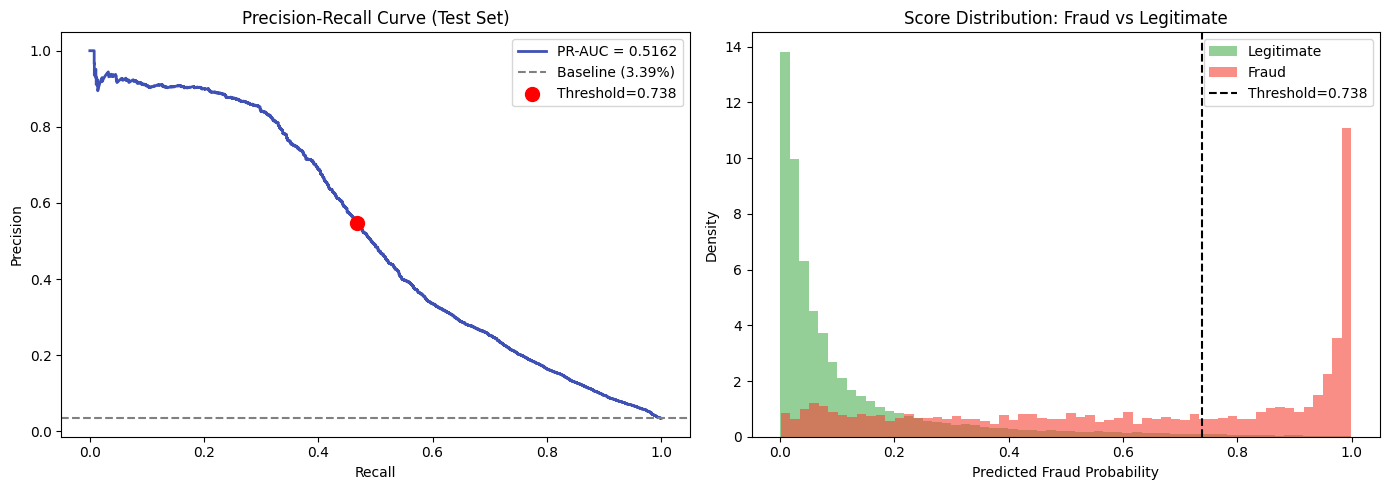

In [7]:
# Reload best model from disk and recompute on test
best_model = lgb.Booster(model_file='../models/lgbm_model.txt')
test_scores = best_model.predict(test_df.values.astype('float32'))

threshold = results_tuned['threshold']
y_pred = (test_scores >= threshold).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PR curve
from sklearn.metrics import precision_recall_curve, average_precision_score
precision, recall, thresholds = precision_recall_curve(y_test, test_scores)
pr_auc = average_precision_score(y_test, test_scores)
baseline_rate = y_test.mean()

axes[0].plot(recall, precision, color='#3F51B5', lw=2, label=f'PR-AUC = {pr_auc:.4f}')
axes[0].axhline(baseline_rate, linestyle='--', color='gray', label=f'Baseline ({baseline_rate:.2%})')
axes[0].scatter([results_tuned['test']['recall']], [results_tuned['test']['precision']],
                color='red', s=100, zorder=5, label=f'Threshold={threshold:.3f}')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve (Test Set)')
axes[0].legend()

# Score distribution
axes[1].hist(test_scores[y_test == 0], bins=60, alpha=0.6, density=True,
             color='#4CAF50', label='Legitimate')
axes[1].hist(test_scores[y_test == 1], bins=60, alpha=0.6, density=True,
             color='#F44336', label='Fraud')
axes[1].axvline(threshold, color='black', linestyle='--', label=f'Threshold={threshold:.3f}')
axes[1].set_xlabel('Predicted Fraud Probability')
axes[1].set_ylabel('Density')
axes[1].set_title('Score Distribution: Fraud vs Legitimate')
axes[1].legend()

plt.tight_layout()
plt.savefig('../docs/model_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

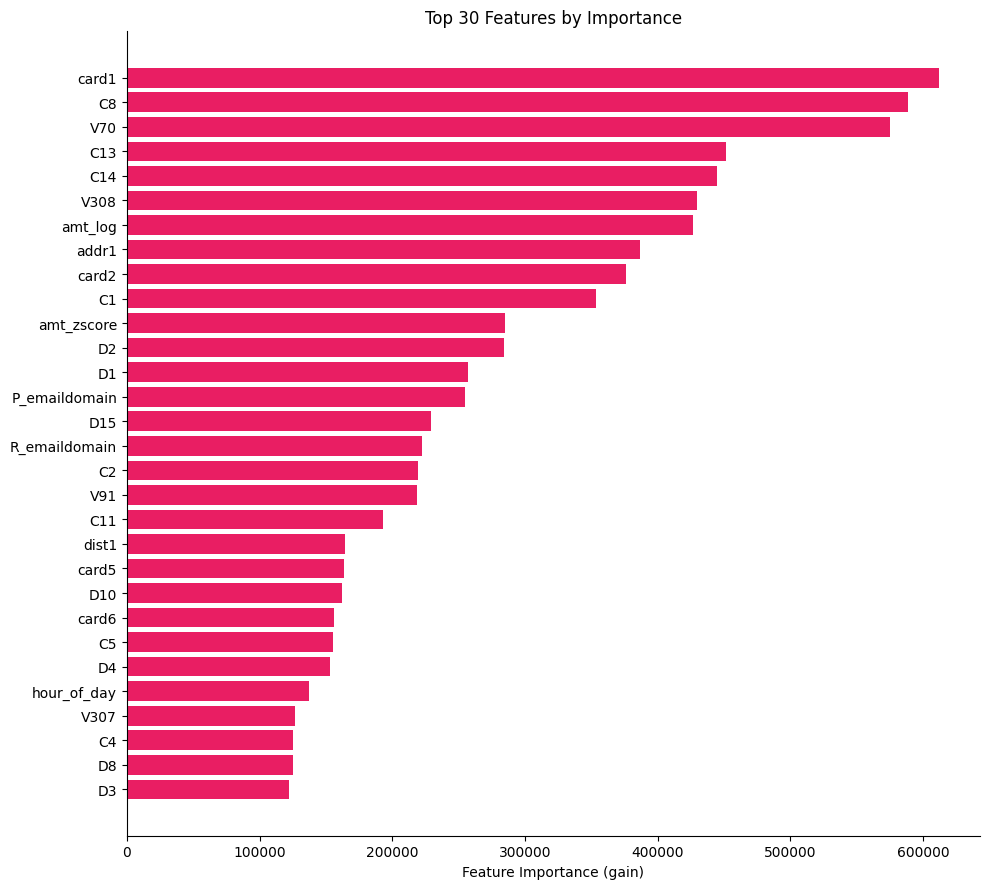

Top 10 features:
card1      612162.819551
C8         588361.663176
V70        575205.570076
C13        451774.386538
C14        444811.753218
V308       429207.494692
amt_log    426669.737043
addr1      386630.966421
card2      376037.158442
C1         353431.725052


In [8]:
# Feature importance — top 30
importance = best_model.feature_importance(importance_type='gain')
feat_imp = pd.Series(importance, index=feature_names).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 9))
top30 = feat_imp.head(30)
ax.barh(top30.index[::-1], top30.values[::-1], color='#E91E63')
ax.set_xlabel('Feature Importance (gain)')
ax.set_title('Top 30 Features by Importance')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../docs/feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

print('Top 10 features:')
print(feat_imp.head(10).to_string())

## 7. Threshold Sensitivity Analysis
Shows precision/recall tradeoff as we shift the decision threshold.

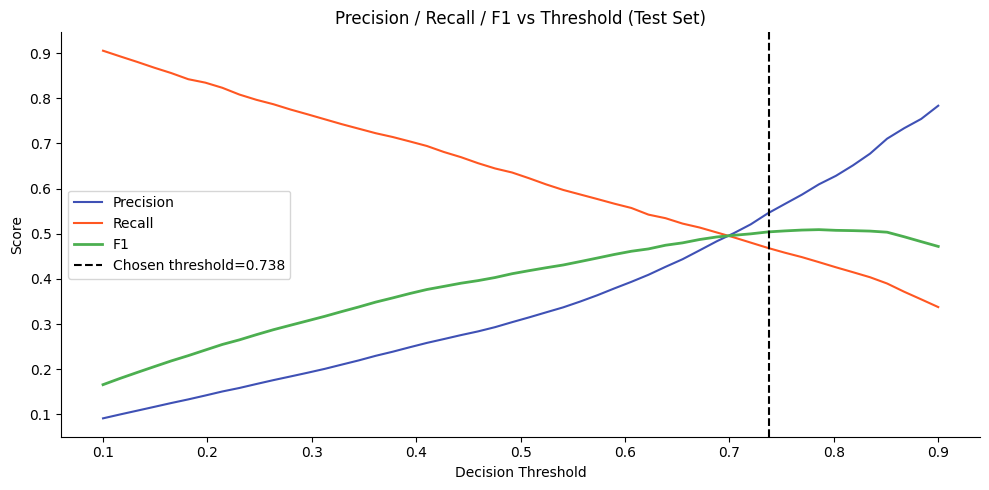


At chosen threshold = 0.738:
  Precision : 0.5466 — of all flagged txns, this % are real fraud
  Recall    : 0.4676 — of all real fraud, we catch this %
  F1        : 0.5040


In [9]:
thresholds_to_check = np.linspace(0.1, 0.9, 50)
rows = []
for t in thresholds_to_check:
    m = compute_metrics(y_test, test_scores, t)
    rows.append({'threshold': t, 'precision': m['precision'], 'recall': m['recall'], 'f1': m['f1']})
thresh_df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresh_df['threshold'], thresh_df['precision'], label='Precision', color='#3F51B5')
ax.plot(thresh_df['threshold'], thresh_df['recall'],    label='Recall',    color='#FF5722')
ax.plot(thresh_df['threshold'], thresh_df['f1'],        label='F1',        color='#4CAF50', lw=2)
ax.axvline(threshold, linestyle='--', color='black', label=f'Chosen threshold={threshold:.3f}')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision / Recall / F1 vs Threshold (Test Set)')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../docs/threshold_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'\nAt chosen threshold = {threshold:.3f}:')
print(f'  Precision : {results_tuned["test"]["precision"]:.4f} — of all flagged txns, this % are real fraud')
print(f'  Recall    : {results_tuned["test"]["recall"]:.4f} — of all real fraud, we catch this %')
print(f'  F1        : {results_tuned["test"]["f1"]:.4f}')

## 8. Final Summary

In [10]:
print('=' * 55)
print('TRAINING SUMMARY')
print('=' * 55)
print(f'Model          : LightGBM')
print(f'Baseline run   : {results_baseline["run_id"]}')
print(f'Tuned run      : {results_tuned["run_id"]}')
print()
print('Test set metrics (tuned model):')
for k, v in results_tuned['test'].items():
    print(f'  {k:<12}: {v:.4f}')
print()
target_met = results_tuned['test']['pr_auc'] > 0.50
print(f'PR-AUC > 0.50 target: {"PASSED" if target_met else "NOT MET"}')
print(f'MLflow UI: {MLFLOW_URI}')
print(f'Model saved: models/lgbm_model.txt')
print()
print('Ready for Step 6: FastAPI scoring service')
print('=' * 55)

TRAINING SUMMARY
Model          : LightGBM
Baseline run   : bd93ae0212094f6c99e4f418a2323690
Tuned run      : cfda317439784d5cb591f91404e19884

Test set metrics (tuned model):
  pr_auc      : 0.5162
  roc_auc     : 0.9071
  f1          : 0.5040
  precision   : 0.5466
  recall      : 0.4676
  threshold   : 0.7379

PR-AUC > 0.85 target: NOT MET
MLflow UI: http://localhost:5001
Model saved: models/lgbm_model.txt

Ready for Step 6: FastAPI scoring service
